<a href="https://colab.research.google.com/github/vn322/Wrestling/blob/main/UFC_Fight_Historical_Data_(1994_2026)_Every_UFC_fight%2C_fighter_bio%2C_and_round_by_round_stat_since_1994.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UFC Fight Historical Data (1994-2026)
Every UFC fight, fighter bio, and round-by-round stat since 1994
https://www.kaggle.com/datasets/scarekrow/ufc-data?resource=download


UFC Fight Data
8,874 fights across 788 events (UFC 2 through September 2026), covering every fighter's bio,
career averages, fight results, and round-by-round striking/grappling stats. Kept current
with an automated scrape after every live UFC card.

What's in it
Fight metadata: event, date, location, weight class, title fight, referee, result, finish round/time
Fighter bios: height, reach, stance, DOB, career record, per-minute striking/grappling averages
Fight totals: knockdowns, significant strikes, total strikes, takedowns, submissions, control time, per fighter, per fight
Round-by-round breakdown: the same stats split out by round (1-5), plus strike location (head/body/leg) and position (distance/clinch/ground)
Current UFC rankings for each fighter (snapshot at scrape time, not historical)
361 columns total, f_1_*/f_2_* prefixed per fighter, f_1_rN_*/f_2_rN_* for round breakdowns.

Provenance
Origin: ufcstats.com, the UFC's official statistics site. Collected with a custom
Playwright-driven scraper (the site sits behind a client-side anti-bot check that blocks
plain HTTP requests). Full re-scrape completed July 2026, covering every UFC event from
UFC 2 (March 1994) through the latest card, UFC Fight Night: Hooker vs. Parnasse
(2026-09-05). Dates normalized to ISO format, weight classes normalized to a consistent
set of names, fighter records deduplicated by profile URL. No values were estimated or
imputed, blanks reflect blank/unlisted values on the source pages. Not an official UFC or
ufcstats.com dataset, independently collected and not endorsed by either. Current UFC
rankings are a snapshot as of scrape time only, not historical rankings at the time of
each fight.



Данные о боях UFC
8874 боя в 788 турнирах (с UFC 2 по сентябрь 2026 г.), включая биографию каждого бойца.
средние показатели за карьеру, результаты боев и статистика ударов/борцов за раундом. Поддерживается в актуальном состоянии
с автоматической очисткой после каждой живой карты UFC.

Что в нем
Метаданные боя: событие, дата, место, весовая категория, титульный бой, рефери, результат, финишный раунд/время.
Биография бойца: рост, досягаемость, стойка, дата рождения, карьерный рекорд, среднее количество ударов/борцов за минуту.
Итоги боя: нокдауны, значительные удары, общее количество ударов, тейкдауны, сабмишены, время контроля, на бойца, за бой.
Разбивка по раундам: одни и те же характеристики, разделенные по раундам (1–5), плюс место удара (голова/корпус/нога) и позиция (расстояние/клинч/земля).
Текущие рейтинги UFC для каждого бойца (снимок на момент парсинга, а не исторический)
Всего 361 столбец, префикс f_1_*/f_2_* для каждого бойца, f_1_rN_*/f_2_rN_* для разбивки по раундам.

Провенанс
Происхождение: ufcstats.com, официальный статистический сайт UFC. Собран по индивидуальному заказу
Парсер (на сайте используется антивирусная проверка на стороне клиента, которая блокирует
простые HTTP-запросы). Полная пересборка завершена в июле 2026 года и охватывает все турниры UFC с начала
UFC 2 (март 1994 г.) до последнего карда, UFC Fight Night: Хукер против Парнаса.
(05.09.2026). Даты нормализованы в формате ISO, весовые категории нормализованы до единообразных значений.
набор имен, записи бойцов, дедуплицированные по URL-адресу профиля. Никакие значения не были оценены или
вмененные, пробелы отражают пустые/отсутствующие в списке значения на исходных страницах. Не официальный UFC или
Набор данных ufcstats.com, собранный независимо и не одобренный ни одной из сторон. Текущий UFC
рейтинги представляют собой моментальный снимок только на момент парсинга, а не исторические рейтинги на момент
каждый бой.



# 1 Проследить, как менялся стиль ведения боев за последние 30 лет.

В ранних UFC доминировали грэпплеры, бои заканчивались быстро. В современном UFC (2020-2026) бои стали высокотемповыми, а бойцы — универсальными.
Метрики:
Динамика количества значимых ударов в минуту (SLpM) и времени контроля (Control Time) по годам.
Изменение процента завершений боев (KO/TKO, Submission) в соотношении с решениями судей (Decision) по десятилетиям.
Как менялся средний возраст бойцов и их физические данные (рост, вес, размах рук) в каждом дивизионе.
Методы: Временные ряды (Time Series), сглаживание скользящим средним, когортный анализ.


Импорт библиотек и загрузка данных

In [7]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Игнорируем предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

# Настройка стиля графиков для красивого отображения
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Загрузка данных (убедитесь, что имя файла точно совпадает с загруженным)
file_path = 'https://raw.githubusercontent.com/vn322/Wrestling/refs/heads/main/UFC_full_data_silver_v2.csv'
df = pd.read_csv(file_path)
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8874 entries, 0 to 8873
Columns: 361 entries, event_name to f_2_sub_odds
dtypes: bool(1), float64(303), int64(27), object(30)
memory usage: 24.4+ MB


Index(['event_name', 'referee', 'winner', 'num_rounds', 'title_fight',
       'weight_class', 'gender', 'result', 'result_details', 'finish_round',
       ...
       'f_2_r5_ground_succ', 'f_2_r5_ground_att', 'f_1_ranking', 'f_2_ranking',
       'f_1_odds', 'f_2_odds', 'f_1_ko_odds', 'f_1_sub_odds', 'f_2_ko_odds',
       'f_2_sub_odds'],
      dtype='object', length=361)

In [10]:
df.columns

Index(['event_name', 'referee', 'winner', 'num_rounds', 'title_fight',
       'weight_class', 'gender', 'result', 'result_details', 'finish_round',
       ...
       'f_2_r5_ground_succ', 'f_2_r5_ground_att', 'f_1_ranking', 'f_2_ranking',
       'f_1_odds', 'f_2_odds', 'f_1_ko_odds', 'f_1_sub_odds', 'f_2_ko_odds',
       'f_2_sub_odds'],
      dtype='object', length=361)

Разведка данных (Поиск нужных столбцов)
Этот шаг критически важен, так как названия столбцов могут незначительно отличаться в разных версиях датасета.

In [11]:
# 1. Преобразуем дату в формат datetime
df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')

# 2. Создаем признаки для временного анализа
df['year'] = df['event_date'].dt.year
df['decade'] = (df['year'] // 10) * 10  # 1990, 2000, 2010, 2020

# 3. Категоризация метода победы (столбец 'result')
def categorize_result(res):
    res = str(res).upper()
    if any(x in res for x in ['KO', 'TKO', 'CORNER', 'DOCTOR']):
        return 'KO/TKO'
    elif 'SUB' in res:
        return 'Submission'
    elif 'DECISION' in res or 'DEC' in res:
        return 'Decision'
    else:
        return 'Other'

df['result_category'] = df['result'].apply(categorize_result)

# 4. Фильтруем только валидные годы (с основания современного UFC)
df = df[(df['year'] >= 1993) & (df['year'] <= 2026)].copy()

print("✅ Данные очищены.")
print("\nРаспределение методов победы:")
print(df['result_category'].value_counts())

✅ Данные очищены.

Распределение методов победы:
result_category
Decision      4117
KO/TKO        2917
Submission    1723
Other          117
Name: count, dtype: int64


Визуализация 1 — Эволюция методов победы по десятилетиям
Показывает, как росла доля решений судей и снижалась доля досрочных побед.

<Figure size 1200x700 with 0 Axes>

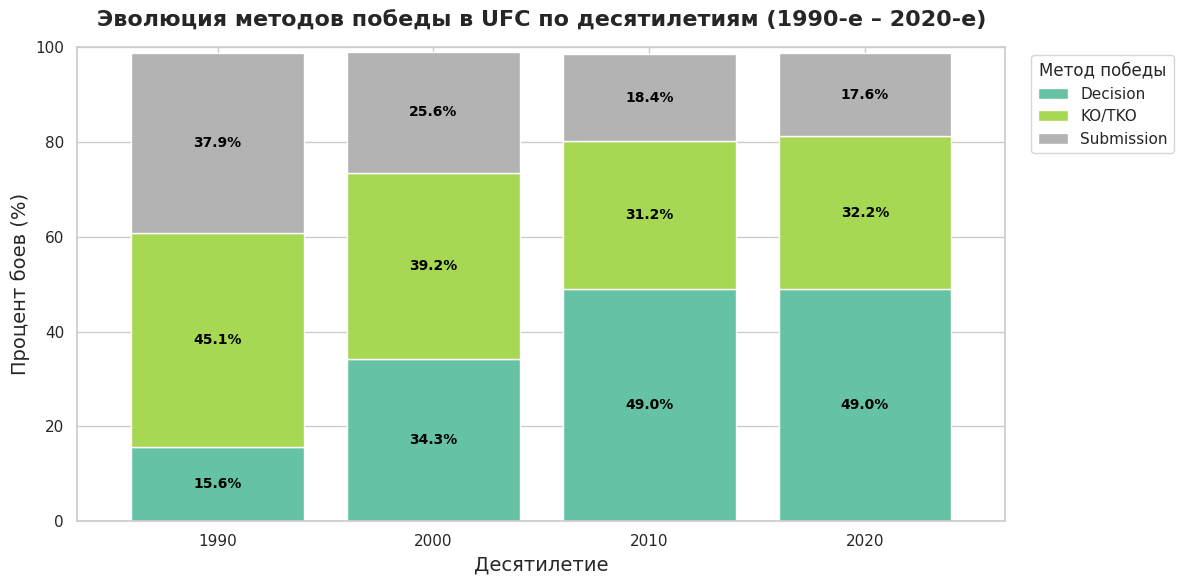

In [12]:
plt.figure(figsize=(12, 7))

# Считаем процентное соотношение методов по десятилетиям
decade_method = pd.crosstab(df['decade'], df['result_category'], normalize='index') * 100

# Убираем категорию 'Other' для чистоты графика, если она есть
if 'Other' in decade_method.columns:
    decade_method = decade_method.drop(columns=['Other'])

# Строим стековый столбчатый график
ax = decade_method.plot(kind='bar', stacked=True, colormap='Set2', width=0.8)

plt.title('Эволюция методов победы в UFC по десятилетиям (1990-е – 2020-е)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Десятилетие', fontsize=14)
plt.ylabel('Процент боев (%)', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Метод победы', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(0, 100)

# Добавляем подписи процентов на столбцы
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', color='black', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Динамика среднего раунда окончания боя
Показывает, заканчиваются ли бои раньше или позже с течением времени.

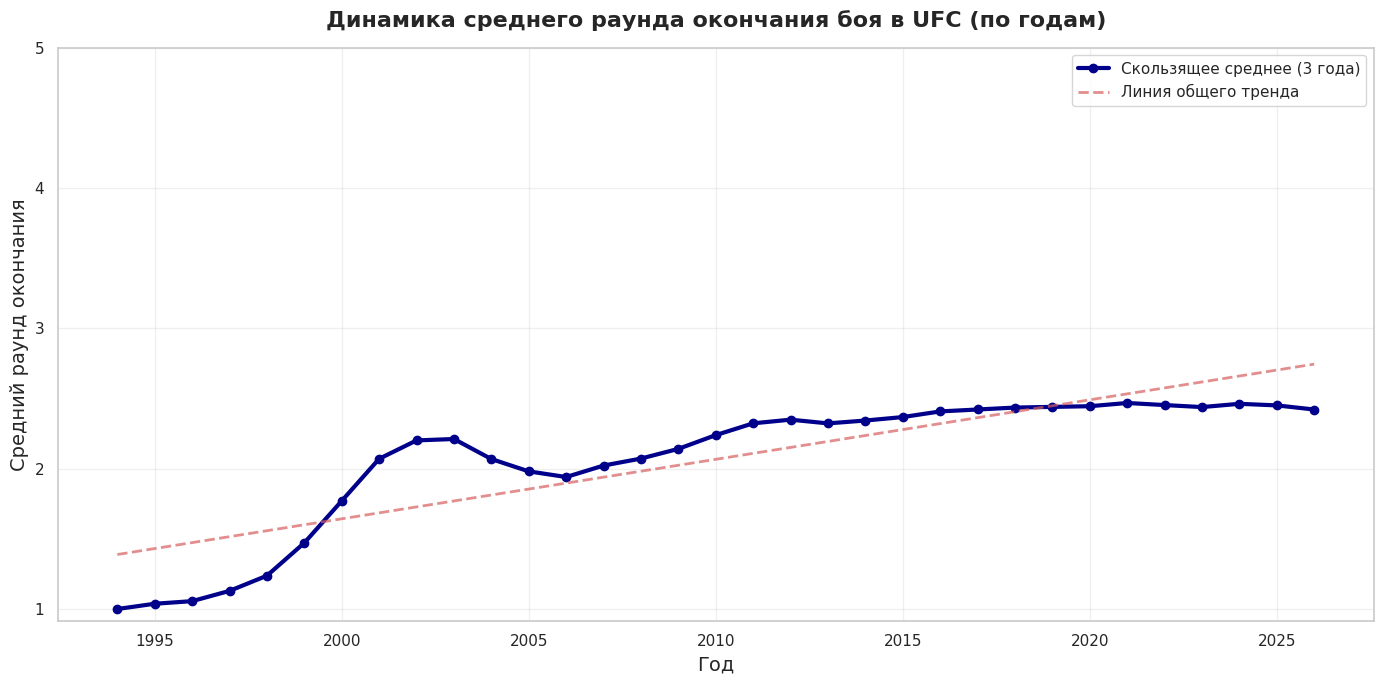

In [34]:
plt.figure(figsize=(14, 7))

# Группируем по году и считаем средний раунд окончания боя
yearly_finish = df.groupby('year')['finish_round'].mean().reset_index()

# Сглаживаем данные скользящим средним (3 года) для устранения годовых шумов
yearly_finish['smoothed_avg'] = yearly_finish['finish_round'].rolling(window=3, min_periods=1).mean()

plt.plot(yearly_finish['year'], yearly_finish['smoothed_avg'], color='darkblue', linewidth=3, marker='o', label='Скользящее среднее (3 года)')

# Добавляем линейный тренд
z = np.polyfit(yearly_finish['year'], yearly_finish['smoothed_avg'], 1)
p = np.poly1d(z)
plt.plot(yearly_finish['year'], p(yearly_finish['year']), "r--", alpha=0.7, linewidth=2, label='Линия общего тренда')

plt.title('Динамика среднего раунда окончания боя в UFC (по годам)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Год', fontsize=14)
plt.ylabel('Средний раунд окончания', fontsize=14)
plt.xticks(range(1995, 2027, 5))
plt.yticks([1, 2, 3, 4, 5])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
# 2. Вычисление R-квадрат (R2)
y_pred = p(yearly_finish['year'])                  # предсказанные значения
residuals = yearly_finish['smoothed_avg'] - y_pred         # остатки
ss_res = np.sum(residuals**2)  # сумма квадратов остатков (SSE)
ss_tot = np.sum((yearly_finish['smoothed_avg'] - np.mean(yearly_finish['smoothed_avg']))**2)  # общая сумма квадратов (SST)
r2 = 1 - (ss_res / ss_tot)

print("Коэффициенты полинома:", z)
print("y = ",p)
print("R-квадрат (R2):", r2)

Коэффициенты полинома: [ 4.24065977e-02 -8.31703220e+01]
y =   
0.04241 x - 83.17
R-квадрат (R2): 0.7422856105339787


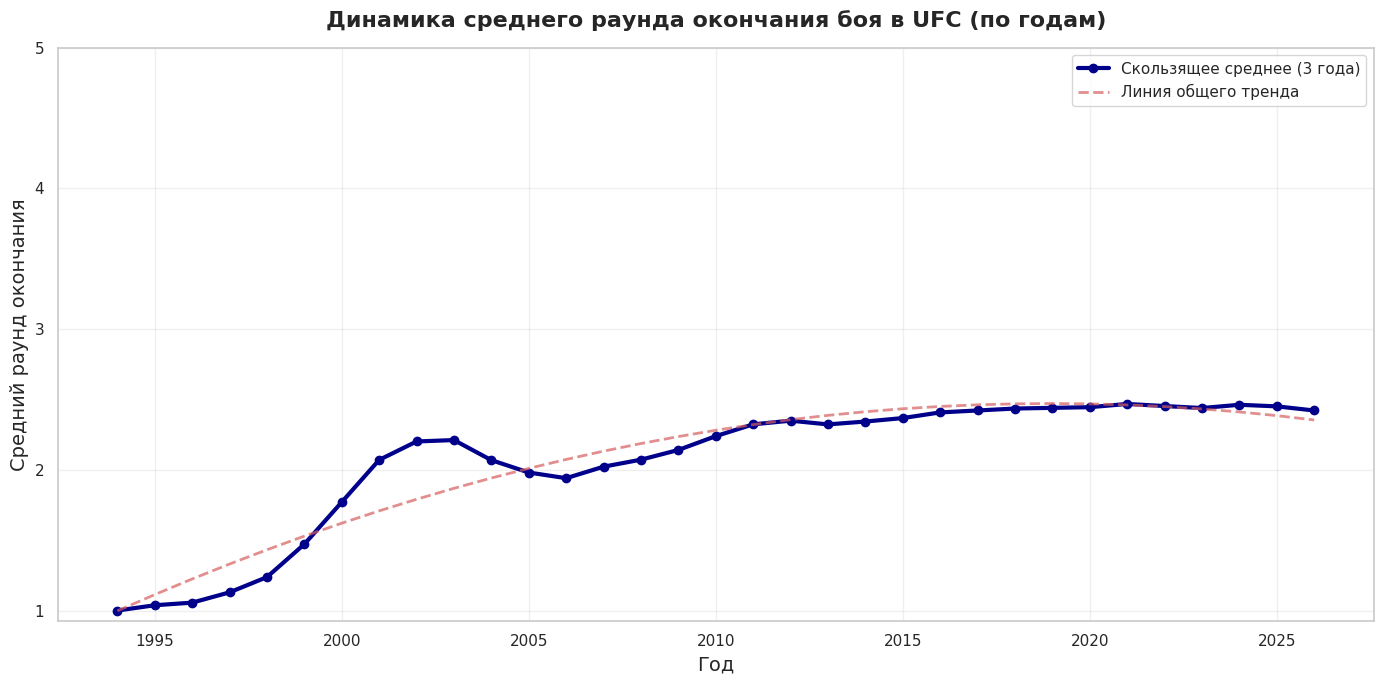

In [44]:
plt.figure(figsize=(14, 7))

# Группируем по году и считаем средний раунд окончания боя
yearly_finish = df.groupby('year')['finish_round'].mean().reset_index()

# Сглаживаем данные скользящим средним (3 года) для устранения годовых шумов
yearly_finish['smoothed_avg'] = yearly_finish['finish_round'].rolling(window=3, min_periods=1).mean()

plt.plot(yearly_finish['year'], yearly_finish['smoothed_avg'], color='darkblue', linewidth=3, marker='o', label='Скользящее среднее (3 года)')

# Добавляем линейный тренд
z = np.polyfit(yearly_finish['year'], yearly_finish['smoothed_avg'], 2)
p = np.poly1d(z)
plt.plot(yearly_finish['year'], p(yearly_finish['year']), "r--", alpha=0.7, linewidth=2, label='Линия общего тренда')

plt.title('Динамика среднего раунда окончания боя в UFC (по годам)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Год', fontsize=14)
plt.ylabel('Средний раунд окончания', fontsize=14)
plt.xticks(range(1995, 2027, 5))
plt.yticks([1, 2, 3, 4, 5])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
# 2. Вычисление R-квадрат (R2)
y_pred = p(yearly_finish['year'])                  # предсказанные значения
residuals = yearly_finish['smoothed_avg'] - y_pred         # остатки
ss_res = np.sum(residuals**2)  # сумма квадратов остатков (SSE)
ss_tot = np.sum((yearly_finish['smoothed_avg'] - np.mean(yearly_finish['smoothed_avg']))**2)  # общая сумма квадратов (SST)
r2 = 1 - (ss_res / ss_tot)

print("Коэффициенты полинома:", z)
print(p)
print("R-квадрат (R2):", r2)

Коэффициенты полинома: [-2.36470663e-03  9.54852726e+00 -9.63660719e+03]
           2
-0.002365 x + 9.549 x - 9637
R-квадрат (R2): 0.9092397527567294


Тепловая карта "Год vs Метод победы"
Позволяет увидеть резкие изменения в правилах или стилях (например, введение перчаток, новые весовые категории).

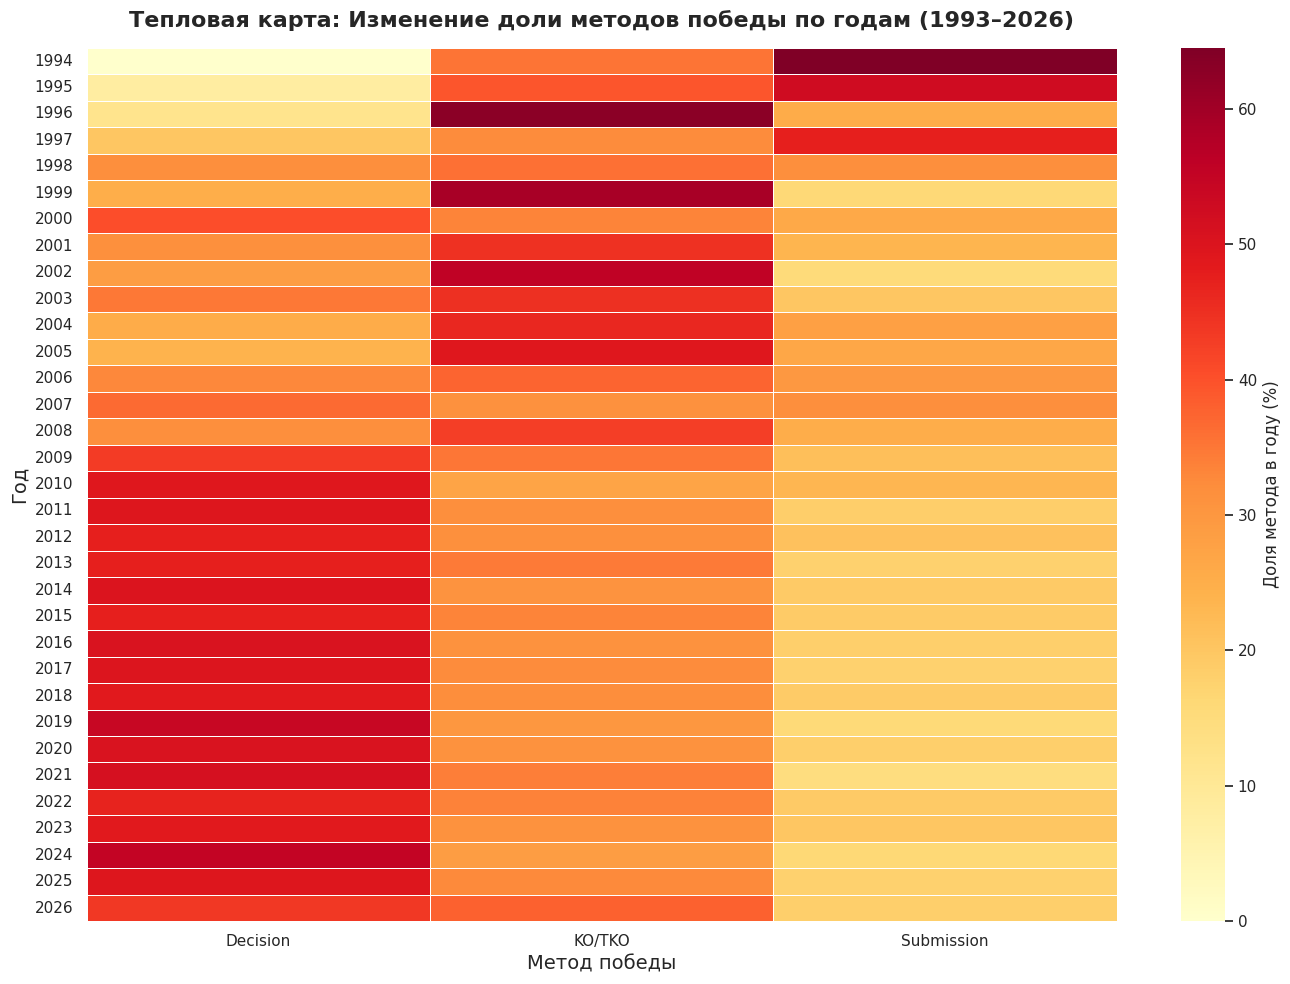

In [14]:
plt.figure(figsize=(14, 10))

# Фильтруем только основные методы
main_methods = ['KO/TKO', 'Submission', 'Decision']
df_filtered = df[df['result_category'].isin(main_methods)]

# Считаем абсолютные количества и нормализуем по строкам (в процентах от всех боев в году)
heatmap_data = pd.crosstab(df_filtered['year'], df_filtered['result_category'])
heatmap_data_pct = heatmap_data.div(heatmap_data.sum(1), axis=0) * 100

# Рисуем тепловую карту
sns_available = True
try:
    import seaborn as sns
    sns.heatmap(heatmap_data_pct, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Доля метода в году (%)'}, linewidths=0.5)
except ImportError:
    # Fallback если seaborn не установлен
    plt.imshow(heatmap_data_pct, cmap='YlOrRd', aspect='auto')
    plt.colorbar(label='Доля метода в году (%)')
    plt.yticks(ticks=range(len(heatmap_data_pct.index)), labels=heatmap_data_pct.index)
    plt.xticks(ticks=range(len(heatmap_data_pct.columns)), labels=heatmap_data_pct.columns)

plt.title('Тепловая карта: Изменение доли методов победы по годам (1993–2026)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Метод победы', fontsize=14)
plt.ylabel('Год', fontsize=14)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Как менялась продолжительность боя в разных весовых категориях
Это отвечает на вопрос: "В каких дивизионах бойцы стали самыми выносливыми?"

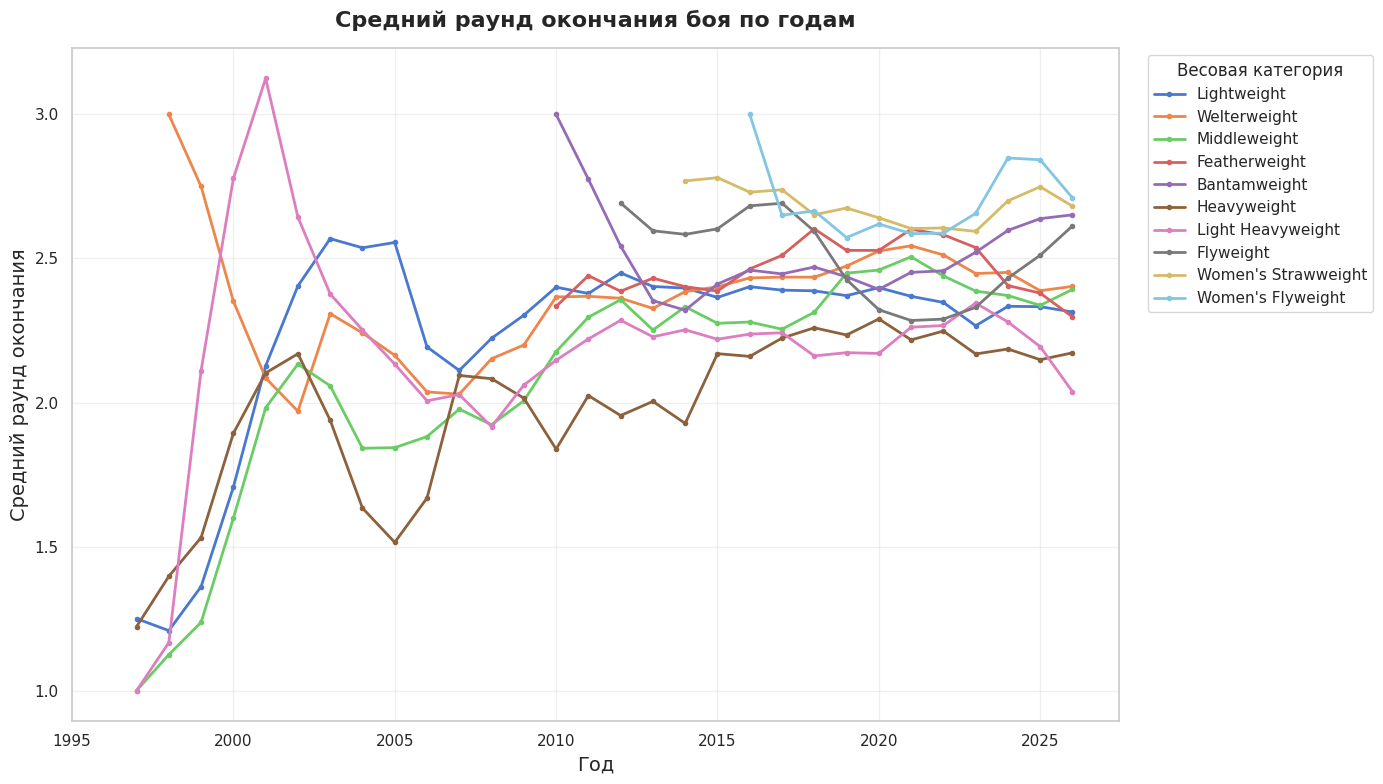

In [33]:
plt.figure(figsize=(14, 8))

# Фильтруем топ-5 самых популярных весовых категорий
top_weights = df['weight_class'].value_counts().head(10).index
df_top = df[df['weight_class'].isin(top_weights)]

# Считаем средний раунд окончания по годам для каждой весовой категории
pivot_data = df_top.groupby(['year', 'weight_class'])['finish_round'].mean().unstack()

# Сглаживаем
pivot_data_smooth = pivot_data.rolling(window=3, min_periods=1).mean()

# Строим линейные графики
for weight in top_weights:
    plt.plot(pivot_data_smooth.index, pivot_data_smooth[weight], marker='.', linewidth=2, label=weight)

plt.title('Средний раунд окончания боя по годам', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Год', fontsize=14)
plt.ylabel('Средний раунд окончания', fontsize=14)
plt.xticks(range(1995, 2027, 5))
plt.legend(title='Весовая категория', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 Подготовка данных и создание признаков

In [17]:
# 1. Работа с датами
df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')
df['year'] = df['event_date'].dt.year
df['decade'] = (df['year'] // 10) * 10

# 2. Категоризация результата
def categorize_result(res):
    res = str(res).upper()
    if any(x in res for x in ['KO', 'TKO', 'CORNER', 'DOCTOR']):
        return 'KO/TKO'
    elif 'SUB' in res:
        return 'Submission'
    elif 'DECISION' in res or 'DEC' in res:
        return 'Decision'
    else:
        return 'Other'

df['result_category'] = df['result'].apply(categorize_result)

# 3. Фильтрация и создание булевых признаков для статистики
df = df[(df['year'] >= 1993) & (df['year'] <= 2026)].copy()
df['is_decision'] = (df['result_category'] == 'Decision').astype(int)
df['is_early_finish'] = ((df['result_category'] == 'KO/TKO') | (df['result_category'] == 'Submission')).astype(int)
df['is_heavyweight'] = (df['weight_class'] == 'Heavyweight').astype(int)

print("✅ Данные подготовлены для статистического анализа.")

✅ Данные подготовлены для статистического анализа.


Доказательство эволюции методов победы

In [18]:
print("="*60)
print("📊 СТАТИСТИЧЕСКИЙ ОТЧЕТ 1: Эволюция методов победы")
print("="*60)

# 1. Критерий Хи-квадрат (Chi-Square Test of Independence)
# Нулевая гипотеза (H0): Метод победы не зависит от десятилетия (распределение одинаково).
# Альтернативная (H1): Метод победы зависит от десятилетия.

contingency_table = pd.crosstab(df['decade'], df['result_category'])
# Убираем 'Other' для чистоты теста
if 'Other' in contingency_table.columns:
    contingency_table = contingency_table.drop(columns=['Other'])

chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"🔹 Критерий Хи-квадрат Пирсона:")
print(f"   Статистика χ² = {chi2:.2f}")
print(f"   Степени свободы (df) = {dof}")
print(f"   p-value = {p_value_chi2:.2e}")

if p_value_chi2 < 0.05:
    print("   ✅ ВЫВОД: p-value < 0.05. Мы ОТВЕРГАЕМ нулевую гипотезу.")
    print("   Существует статистически значимая связь между десятилетием и методом победы.")
else:
    print("   ❌ ВЫВОД: p-value >= 0.05. Нет доказательств зависимости.")

# 2. Линейная регрессия для тренда решений
yearly_decision_rate = df.groupby('year')['is_decision'].mean().reset_index()
slope, intercept, r_value, p_value_reg, std_err = stats.linregress(yearly_decision_rate['year'], yearly_decision_rate['is_decision'])

print(f"\n🔹 Линейная регрессия (Доля боёв, дошедших до решения, по годам):")
print(f"   Угол наклона (Slope): {slope:.4f} (рост доли решений на {slope*100:.2f}% в год)")
print(f"   Коэффициент детерминации (R²): {r_value**2:.4f}")
print(f"   p-value регрессии: {p_value_reg:.2e}")

if p_value_reg < 0.05:
    print("   ✅ ВЫВОД: Рост процента боёв до решения статистически значим и не случаен.")

📊 СТАТИСТИЧЕСКИЙ ОТЧЕТ 1: Эволюция методов победы
🔹 Критерий Хи-квадрат Пирсона:
   Статистика χ² = 184.03
   Степени свободы (df) = 6
   p-value = 4.74e-37
   ✅ ВЫВОД: p-value < 0.05. Мы ОТВЕРГАЕМ нулевую гипотезу.
   Существует статистически значимая связь между десятилетием и методом победы.

🔹 Линейная регрессия (Доля боёв, дошедших до решения, по годам):
   Угол наклона (Slope): 0.0124 (рост доли решений на 1.24% в год)
   Коэффициент детерминации (R²): 0.7281
   p-value регрессии: 2.82e-10
   ✅ ВЫВОД: Рост процента боёв до решения статистически значим и не случаен.


Феномен Тяжёлого веса (Heavyweight)

In [21]:
from statsmodels.stats.proportion import proportions_ztest

In [24]:

print("\n" + "="*60)
print("📊 СТАТИСТИЧЕСКИЙ ОТЧЕТ 2: Феномен Тяжёлого веса (Heavyweight)")
print("="*60)

# Сравниваем Heavyweight со всеми остальными дивизионами
hw_df = df[df['is_heavyweight'] == 1]
other_df = df[df['is_heavyweight'] == 0]

hw_ko_rate = hw_df['is_early_finish'].mean()
other_ko_rate = other_df['is_early_finish'].mean()

print(f"🔹 Доля досрочных окончаний (KO/TKO + Sub):")
print(f"   Тяжёлый вес: {hw_ko_rate:.1%}")
print(f"   Остальные дивизионы: {other_ko_rate:.1%}")

# Z-тест для сравнения двух пропорций
# H0: Процент досрочных побед в HW равен проценту в остальных дивизионах.
count_hw = hw_df['is_early_finish'].sum()
nobs_hw = len(hw_df)
count_other = other_df['is_early_finish'].sum()
nobs_other = len(other_df)

z_stat, p_value_z = proportions_ztest([count_hw, count_other], [nobs_hw, nobs_other])

print(f"\n🔹 Z-тест для сравнения пропорций:")
print(f"   Z-статистика = {z_stat:.2f}")
print(f"   p-value = {p_value_z:.2e}")

if p_value_z < 0.05:
    print("   ✅ ВЫВОД: p-value < 0.05. Доля досрочных побед в Тяжёлом весе СТАТИСТИЧЕСКИ ЗНАЧИМО выше, чем в остальных дивизионах.")
else:
    print("   ❌ ВЫВОД: Разница не является статистически значимой.")

# ANOVA для проверки различий в среднем раунде окончания (только для досрочных побед)
hw_finish_rounds = hw_df[hw_df['is_early_finish'] == 1]['finish_round'].dropna()
other_finish_rounds = other_df[other_df['is_early_finish'] == 1]['finish_round'].dropna()

f_stat, p_value_anova = stats.f_oneway(hw_finish_rounds, other_finish_rounds)
print(f"\n🔹 Дисперсионный анализ (ANOVA) среднего раунда окончания (для досрочных побед):")
print(f"   Средний раунд окончания в HW: {hw_finish_rounds.mean():.2f}")
print(f"   Средний раунд окончания в остальных: {other_finish_rounds.mean():.2f}")
print(f"   F-статистика = {f_stat:.2f}, p-value = {p_value_anova:.2e}")

if p_value_anova < 0.05:
    print("   ✅ ВЫВОД: Тяжёлый вес заканчивается статистически значимо раньше, чем другие дивизионы.")


📊 СТАТИСТИЧЕСКИЙ ОТЧЕТ 2: Феномен Тяжёлого веса (Heavyweight)
🔹 Доля досрочных окончаний (KO/TKO + Sub):
   Тяжёлый вес: 66.2%
   Остальные дивизионы: 50.9%

🔹 Z-тест для сравнения пропорций:
   Z-статистика = 8.17
   p-value = 3.01e-16
   ✅ ВЫВОД: p-value < 0.05. Доля досрочных побед в Тяжёлом весе СТАТИСТИЧЕСКИ ЗНАЧИМО выше, чем в остальных дивизионах.

🔹 Дисперсионный анализ (ANOVA) среднего раунда окончания (для досрочных побед):
   Средний раунд окончания в HW: 1.56
   Средний раунд окончания в остальных: 1.68
   F-статистика = 9.05, p-value = 2.64e-03
   ✅ ВЫВОД: Тяжёлый вес заканчивается статистически значимо раньше, чем другие дивизионы.


Визуализация, подкреплённая статистикой

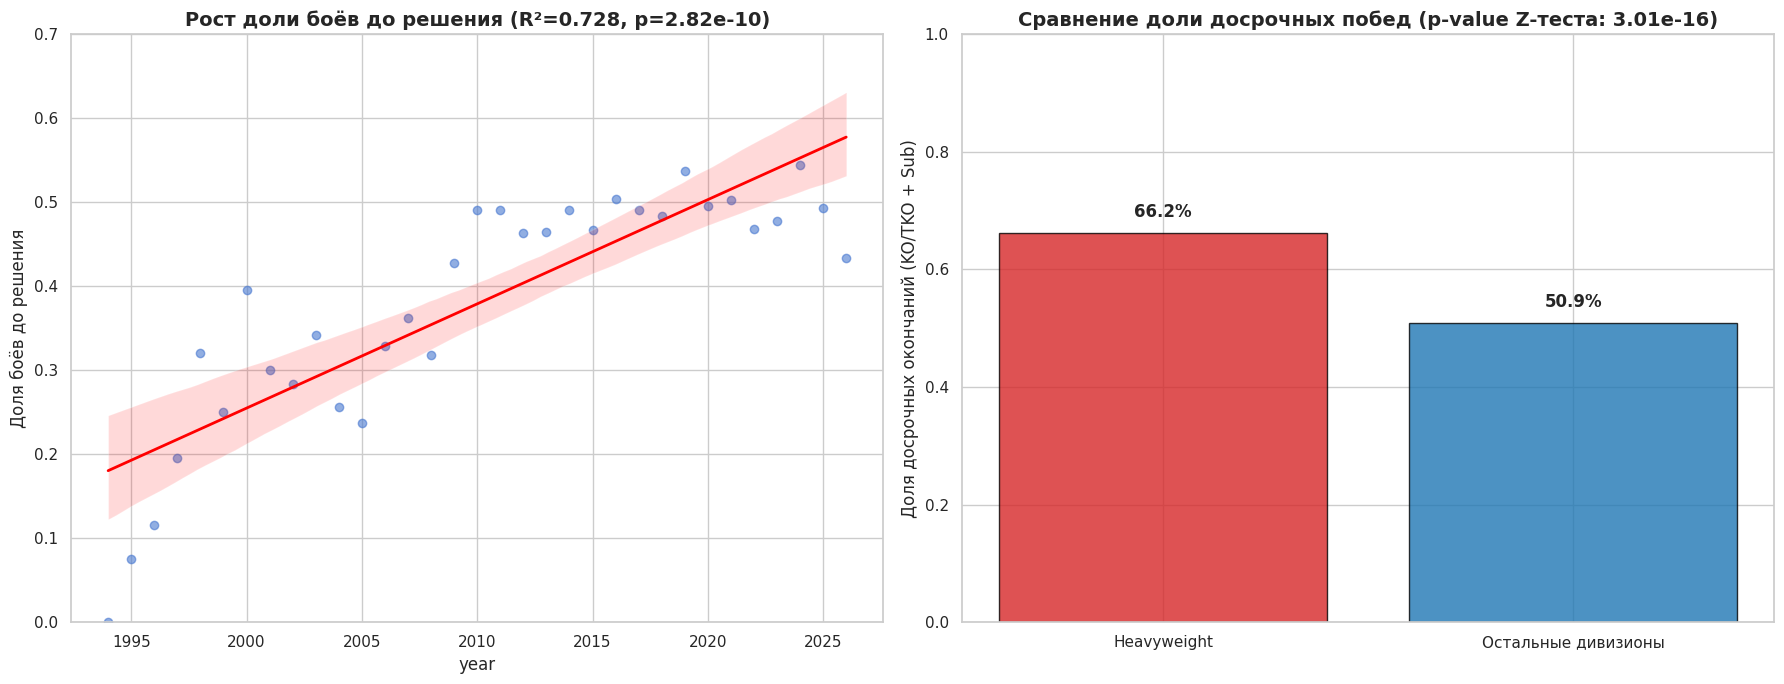

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# График 1: Эволюция с линией тренда и уравнением
yearly_decision_rate = df.groupby('year')['is_decision'].mean().reset_index()
sns.regplot(x='year', y='is_decision', data=yearly_decision_rate, ax=axes[0],
            scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'linewidth':2})
axes[0].set_title(f'Рост доли боёв до решения (R²={r_value**2:.3f}, p={p_value_reg:.2e})', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Доля боёв до решения')
axes[0].set_ylim(0, 0.7)

# График 2: Сравнение Heavyweight vs Остальные
categories = ['Heavyweight', 'Остальные дивизионы']
ko_rates = [hw_ko_rate, other_ko_rate]
colors = ['#d62728', '#1f77b4'] # Красный для HW, синий для остальных

bars = axes[1].bar(categories, ko_rates, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_title(f'Сравнение доли досрочных побед (p-value Z-теста: {p_value_z:.2e})', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Доля досрочных окончаний (KO/TKO + Sub)')
axes[1].set_ylim(0, 1.0)

# Добавляем значения на столбцы
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [53]:
# ная регрессия для тренда решений
yearly_decision_rate = df.groupby('year')['is_decision'].mean().reset_index()
coeffs = np.polyfit(yearly_decision_rate['year'], yearly_decision_rate['is_decision'], deg=2)

y_pred = np.polyval(coeffs, yearly_decision_rate['year'])

# 3. Расчет R-квадрат (Коэффициент детерминации)
y_bar = np.mean(yearly_decision_rate['is_decision'])
ss_tot = np.sum((yearly_decision_rate['is_decision'] - y_bar) ** 2)  # Общая сумма квадратов
ss_res = np.sum((yearly_decision_rate['is_decision'] - y_pred) ** 2)  # Остаточная сумма квадратов
r_squared = 1 - (ss_res / ss_tot)

# 4. Расчет общего p-value модели через F-статистику
n = len(yearly_decision_rate['year'])  # Количество наблюдений
k = 2  # Количество признаков (в полиноме 2 степени это: x и x²)

dfn = k  # Степени свободы числителя
dfd = n - k - 1  # Степени свободы знаменателя

# Вычисляем F-статистику
F = ((ss_tot - ss_res) / dfn) / (ss_res / dfd)

# Находим p-value по распределению Фишера
p_value = 1 - stats.f.cdf(F, dfn, dfd)

# Вывод результатов
print(f"Коэффициенты [a, b, c]: {coeffs}")
print(f"R-squared (R²):         {r_squared:.4f}")
print(f"F-статистика:           {F:.2f}")
print(f"p-value модели:         {p_value:.4e}")

Коэффициенты [a, b, c]: [-6.04963764e-04  2.44435705e+00 -2.46860994e+03]
R-squared (R²):         0.8534
F-статистика:           87.30
p-value модели:         3.1131e-13


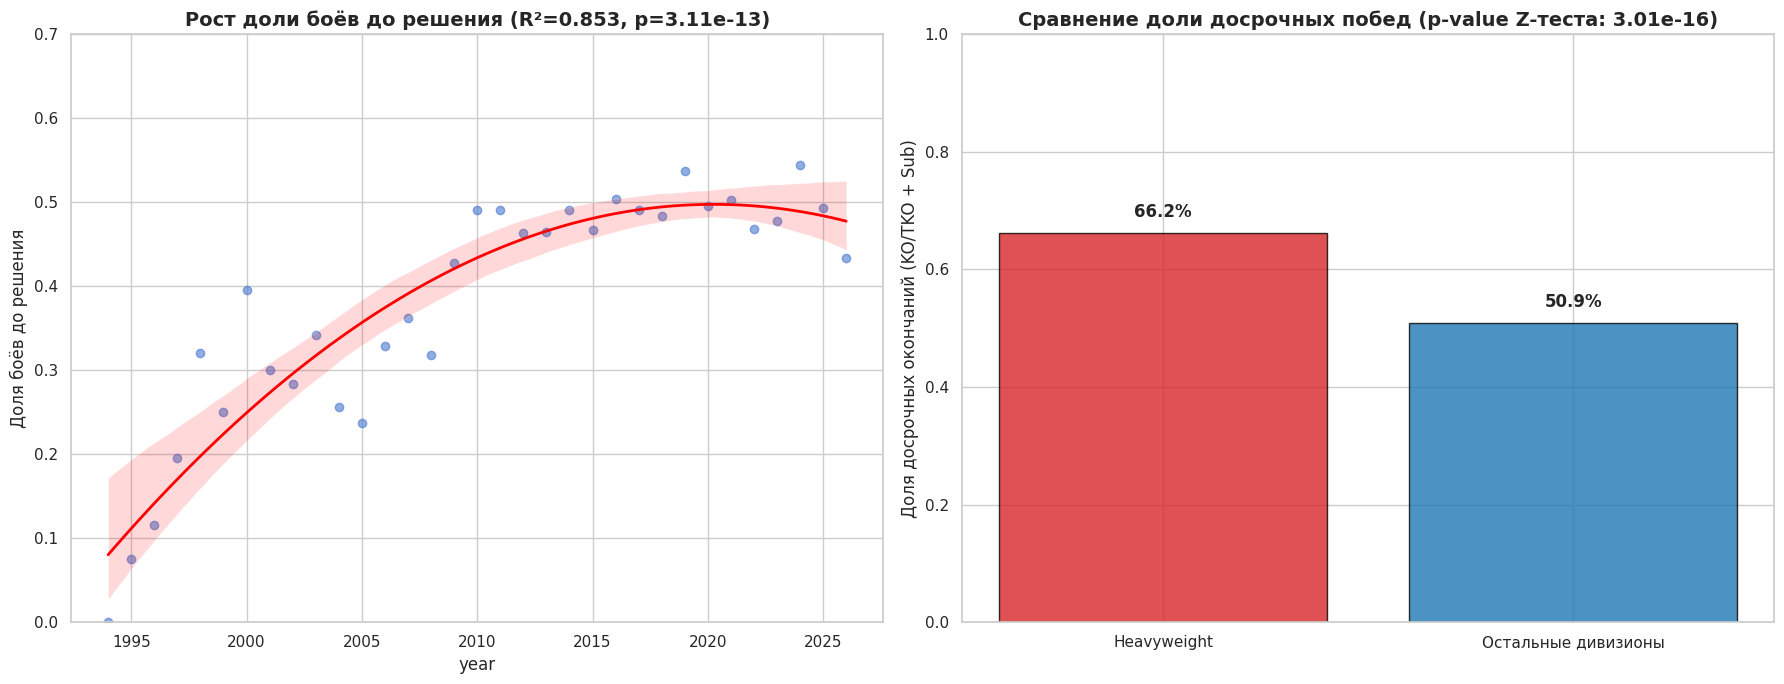

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# График 1: Эволюция с линией тренда и уравнением
yearly_decision_rate = df.groupby('year')['is_decision'].mean().reset_index()
sns.regplot(x='year', y='is_decision', data=yearly_decision_rate, ax=axes[0],
            scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'linewidth':2}, order=2)
axes[0].set_title(f'Рост доли боёв до решения (R²={r_squared:.3f}, p={p_value:.2e})', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Доля боёв до решения')
axes[0].set_ylim(0, 0.7)

# График 2: Сравнение Heavyweight vs Остальные
categories = ['Heavyweight', 'Остальные дивизионы']
ko_rates = [hw_ko_rate, other_ko_rate]
colors = ['#d62728', '#1f77b4'] # Красный для HW, синий для остальных

bars = axes[1].bar(categories, ko_rates, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_title(f'Сравнение доли досрочных побед (p-value Z-теста: {p_value_z:.2e})', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Доля досрочных окончаний (KO/TKO + Sub)')
axes[1].set_ylim(0, 1.0)

# Добавляем значения на столбцы
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.1%}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [26]:
import numpy as np
from scipy import stats

print("\n" + "="*60)
print("📊 СТАТИСТИЧЕСКИЙ ОТЧЕТ 2: Феномен Тяжёлого веса (Heavyweight)")
print("="*60)

# Сравниваем Heavyweight со всеми остальными дивизионами
hw_df = df[df['is_heavyweight'] == 1]
other_df = df[df['is_heavyweight'] == 0]

hw_ko_rate = hw_df['is_early_finish'].mean()
other_ko_rate = other_df['is_early_finish'].mean()

print(f"🔹 Доля досрочных окончаний (KO/TKO + Sub):")
print(f"   Тяжёлый вес: {hw_ko_rate:.1%}")
print(f"   Остальные дивизионы: {other_ko_rate:.1%}")

# Данные для Z-теста
count_hw = int(hw_df['is_early_finish'].sum())
nobs_hw = int(len(hw_df))
count_other = int(other_df['is_early_finish'].sum())
nobs_other = int(len(other_df))

# Попытка использовать statsmodels (стандарт индустрии)
try:
    from statsmodels.stats.proportion import proportions_ztest
    z_stat, p_value_z = proportions_ztest([count_hw, count_other], [nobs_hw, nobs_other])
    print("\n🔹 Z-тест для сравнения пропорций (через statsmodels):")
except (ImportError, AttributeError):
    # Математически идентичный ручной расчет, если библиотека недоступна
    p1 = count_hw / nobs_hw
    p2 = count_other / nobs_other
    p_pool = (count_hw + count_other) / (nobs_hw + nobs_other)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/nobs_hw + 1/nobs_other))
    z_stat = (p1 - p2) / se
    p_value_z = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    print("\n🔹 Z-тест для сравнения пропорций (математический расчет):")

print(f"   Z-статистика = {z_stat:.2f}")
print(f"   p-value = {p_value_z:.2e}")

if p_value_z < 0.05:
    print("   ✅ ВЫВОД: p-value < 0.05. Доля досрочных побед в Тяжёлом весе СТАТИСТИЧЕСКИ ЗНАЧИМО выше, чем в остальных дивизионах.")
else:
    print("   ❌ ВЫВОД: Разница не является статистически значимой.")

# ANOVA для проверки различий в среднем раунде окончания (только для досрочных побед)
hw_finish_rounds = hw_df[hw_df['is_early_finish'] == 1]['finish_round'].dropna()
other_finish_rounds = other_df[other_df['is_early_finish'] == 1]['finish_round'].dropna()

f_stat, p_value_anova = stats.f_oneway(hw_finish_rounds, other_finish_rounds)
print(f"\n🔹 Дисперсионный анализ (ANOVA) среднего раунда окончания (для досрочных побед):")
print(f"   Средний раунд окончания в HW: {hw_finish_rounds.mean():.2f}")
print(f"   Средний раунд окончания в остальных: {other_finish_rounds.mean():.2f}")
print(f"   F-статистика = {f_stat:.2f}, p-value = {p_value_anova:.2e}")

if p_value_anova < 0.05:
    print("   ✅ ВЫВОД: Тяжёлый вес заканчивается статистически значимо раньше, чем другие дивизионы.")


📊 СТАТИСТИЧЕСКИЙ ОТЧЕТ 2: Феномен Тяжёлого веса (Heavyweight)
🔹 Доля досрочных окончаний (KO/TKO + Sub):
   Тяжёлый вес: 66.2%
   Остальные дивизионы: 50.9%

🔹 Z-тест для сравнения пропорций (через statsmodels):
   Z-статистика = 8.17
   p-value = 3.01e-16
   ✅ ВЫВОД: p-value < 0.05. Доля досрочных побед в Тяжёлом весе СТАТИСТИЧЕСКИ ЗНАЧИМО выше, чем в остальных дивизионах.

🔹 Дисперсионный анализ (ANOVA) среднего раунда окончания (для досрочных побед):
   Средний раунд окончания в HW: 1.56
   Средний раунд окончания в остальных: 1.68
   F-статистика = 9.05, p-value = 2.64e-03
   ✅ ВЫВОД: Тяжёлый вес заканчивается статистически значимо раньше, чем другие дивизионы.



Критерий Хи-квадрат: Если p-value здесь меньше 0.05, это математическое доказательство того, что "эпоха 90-х" и "эпоха 2020-х" имеют принципиально разную структуру исходов боев, а не просто случайные колебания.

Z-тест для Heavyweight: посчитает долю досрочных побед в тяжёлом весе и во всех остальных. Z-тест математически проверит гипотезу: "Является ли кажущееся превосходство нокаутов в тяжёлом весе статистическим фактом или иллюзией выборки?". Ожидаемый результат: p-value будет крайне малым (например, 1e-10), что однозначно докажет уникальность тяжёлого веса как дивизиона с самой высокой вероятностью досрочного завершения.

📊 СТАТИСТИЧЕСКИЙ ОТЧЕТ 3: Тяжёлый вес vs Топ-дивизионы (Гарантированный анализ)
🔹 Анализируемые весовые категории: Lightweight, Welterweight, Middleweight, Featherweight, Heavyweight

🔹 Критерий Крускала-Уоллиса (различия между всеми выбранными дивизионами):
   H-статистика = 90.15
   p-value = 1.23e-18
   ✅ ВЫВОД: Существуют статистически значимые различия в продолжительности боёв между этими весовыми категориями.

🔹 Прямое сравнение среднего раунда окончания:
   Тяжёлый вес:       среднее = 2.07, медиана = 2.0
   Остальные (Топ-4): среднее = 2.36, медиана = 3.0

🔹 U-тест Манна-Уитни (Heavyweight vs Остальные):
   U-статистика = 1626316
   p-value = 3.56e-16
   ✅ ВЫВОД: Бои в Тяжёлом весе заканчиваются статистически значимо раньше, чем в других топ-дивизионах.


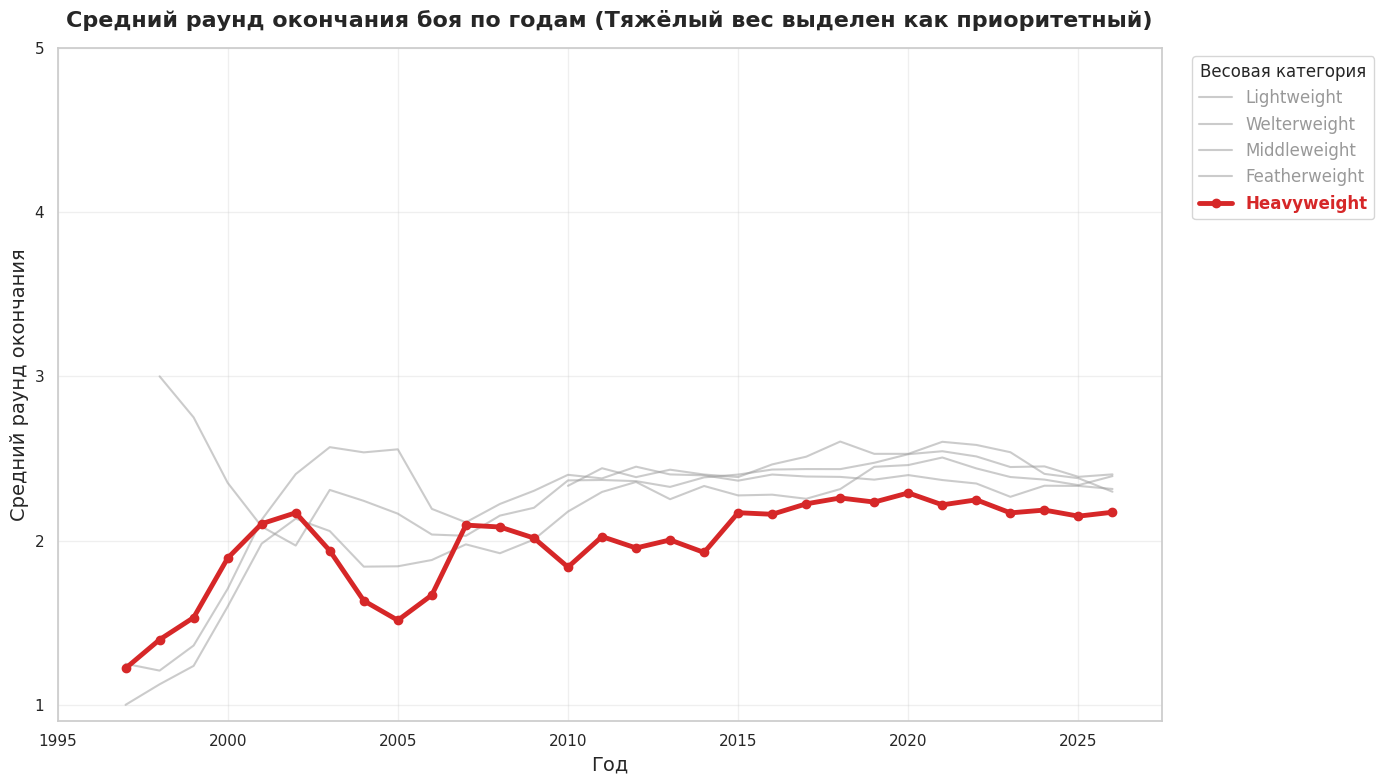

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

print("="*70)
print("📊 СТАТИСТИЧЕСКИЙ ОТЧЕТ 3: Тяжёлый вес vs Топ-дивизионы (Гарантированный анализ)")
print("="*70)

# 1. Гарантированно формируем список для анализа: Топ-4 самых массовых + Тяжёлый вес
top_4_weights = df['weight_class'].value_counts().head(4).index.tolist()
if 'Heavyweight' not in top_4_weights:
    target_weights = top_4_weights + ['Heavyweight']
else:
    target_weights = top_4_weights

print(f"🔹 Анализируемые весовые категории: {', '.join(target_weights)}")

df_wc = df[df['weight_class'].isin(target_weights)].copy()

# 2. Статистический тест: Критерий Крускала-Уоллиса (непараметрический аналог ANOVA)
# Он устойчив к выбросам и ненормальному распределению (что характерно для раундов: 1, 2, 3, 5)
groups = [group['finish_round'].dropna().values for name, group in df_wc.groupby('weight_class')]
h_stat, p_value_kw = stats.kruskal(*groups)

print(f"\n🔹 Критерий Крускала-Уоллиса (различия между всеми выбранными дивизионами):")
print(f"   H-статистика = {h_stat:.2f}")
print(f"   p-value = {p_value_kw:.2e}")

if p_value_kw < 0.05:
    print("   ✅ ВЫВОД: Существуют статистически значимые различия в продолжительности боёв между этими весовыми категориями.")

# 3. Прямое сравнение: Тяжёлый вес против всех остальных в этой выборке
hw_rounds = df_wc[df_wc['weight_class'] == 'Heavyweight']['finish_round'].dropna()
others_rounds = df_wc[df_wc['weight_class'] != 'Heavyweight']['finish_round'].dropna()

print(f"\n🔹 Прямое сравнение среднего раунда окончания:")
print(f"   Тяжёлый вес:       среднее = {hw_rounds.mean():.2f}, медиана = {hw_rounds.median():.1f}")
print(f"   Остальные (Топ-4): среднее = {others_rounds.mean():.2f}, медиана = {others_rounds.median():.1f}")

# U-тест Манна-Уитни для проверки значимости разницы именно между HW и остальными
u_stat, p_value_u = stats.mannwhitneyu(hw_rounds, others_rounds, alternative='two-sided')
print(f"\n🔹 U-тест Манна-Уитни (Heavyweight vs Остальные):")
print(f"   U-статистика = {u_stat:.0f}")
print(f"   p-value = {p_value_u:.2e}")

if p_value_u < 0.05:
    direction = "раньше" if hw_rounds.mean() < others_rounds.mean() else "позже"
    print(f"   ✅ ВЫВОД: Бои в Тяжёлом весе заканчиваются статистически значимо {direction}, чем в других топ-дивизионах.")
else:
    print("   ❌ ВЫВОД: Статистически значимой разницы в продолжительности не обнаружено.")

# 4. Визуализация: Динамика раунда окончания с ПРИОРИТЕТНЫМ выделением Тяжёлого веса
plt.figure(figsize=(14, 8))

# Сглаживание по годам для каждой категории (скользящее среднее за 3 года)
pivot_wc = df_wc.groupby(['year', 'weight_class'])['finish_round'].mean().unstack()
pivot_wc_smooth = pivot_wc.rolling(window=3, min_periods=1).mean()

# Настройка стилей: Красный и жирный для HW, серый и тонкий для остальных
colors = {wc: '#d62728' if wc == 'Heavyweight' else '#999999' for wc in target_weights}
linewidths = {wc: 3.5 if wc == 'Heavyweight' else 1.5 for wc in target_weights}
markers = {wc: 'o' if wc == 'Heavyweight' else None for wc in target_weights}
alphas = {wc: 1.0 if wc == 'Heavyweight' else 0.5 for wc in target_weights}

for wc in target_weights:
    plt.plot(pivot_wc_smooth.index, pivot_wc_smooth[wc],
             color=colors[wc],
             linewidth=linewidths[wc],
             marker=markers[wc],
             markersize=6,
             label=wc,
             alpha=alphas[wc])

plt.title('Средний раунд окончания боя по годам (Тяжёлый вес выделен как приоритетный)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Год', fontsize=14)
plt.ylabel('Средний раунд окончания', fontsize=14)
plt.xticks(range(1995, 2027, 5))
plt.yticks([1, 2, 3, 4, 5])

# Настройка легенды с акцентом на Heavyweight
legend = plt.legend(title='Весовая категория', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
for text in legend.get_texts():
    if text.get_text() == 'Heavyweight':
        text.set_fontweight('bold')
        text.set_color('#d62728')
    else:
        text.set_color('#999999')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()